# Twitter Sentiment Analysis

## ⚙️ Environment Setup

In [6]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contractions
import tensorflow as tf
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings('ignore')

### 🔒 Reproducibility Configuration

In [7]:
# --- Reproducibility ---
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU (TF): {tf.config.list_physical_devices('GPU')}")
print(f"GPU (Torch): {torch.cuda.is_available()}")

# Detect device for PyTorch embedding extraction
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

TensorFlow version: 2.20.0
PyTorch version: 2.11.0+cu128
GPU (TF): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU (Torch): True
Using device: cuda


---
## 📊 Step 1: Data Loading & EDA

### 1.1 Load Dataset

In [ ]:
df = pd.read_csv('merged_twitter_sentiment.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nNull values:\n{df.isnull().sum()}")

Dataset shape: (50822, 4)

Null values:
id             0
topic          0
sentiment      0
text         264
dtype: int64


### 1.2 Class Distribution

In [18]:
print(f"\n--- Sentiment Distribution ---")
sent_counts = df['sentiment'].value_counts()
sent_pct = df['sentiment'].value_counts(normalize=True) * 100
for s in sent_counts.index:
    print(f"  {s}: {sent_counts[s]} ({sent_pct[s]:.1f}%)")


--- Sentiment Distribution ---
  Negative: 18785 (37.0%)
  Positive: 18241 (35.9%)
  Neutral: 9945 (19.6%)
  Irrelevant: 3851 (7.6%)


### 1.3 Topic Distribution

In [19]:
print(f"\nUnique topics ({df['topic'].nunique()}): {df['topic'].unique().tolist()}")
print(f"\n--- Topic Distribution ---")
print(df['topic'].value_counts().to_string())


Unique topics (13): ['Amazon', 'Xbox(Xseries)', 'PlayStation5(PS5)', 'Google', 'League Of Legends', 'Microsoft', 'Verizon', 'HomeDepot', 'Facebook', 'johnson&johnson', 'Nvidia', 'Apple', 'hotel']

--- Topic Distribution ---
topic
hotel                23113
League Of Legends     2431
Microsoft             2428
Verizon               2414
Facebook              2403
johnson&johnson       2367
Xbox(Xseries)         2360
Amazon                2350
PlayStation5(PS5)     2343
Nvidia                2333
HomeDepot             2328
Google                2322
Apple                 1630


### 1.4 Sample Rows

In [20]:
print(f"\n--- Sample Rows ---")
print(df.head(5).to_string())


--- Sample Rows ---
   id   topic sentiment            text
0   0  Amazon  Negative  @amazon wtf . 
1   1  Amazon  Negative   @ amazon wtf.
2   2  Amazon  Negative   @ amazon wtf.
3   3  Amazon  Negative    @amazon wtf?
4   4  Amazon  Negative  7 @amazon wtf.


### 1.5 Visualization: Sentiment & Topic Distribution

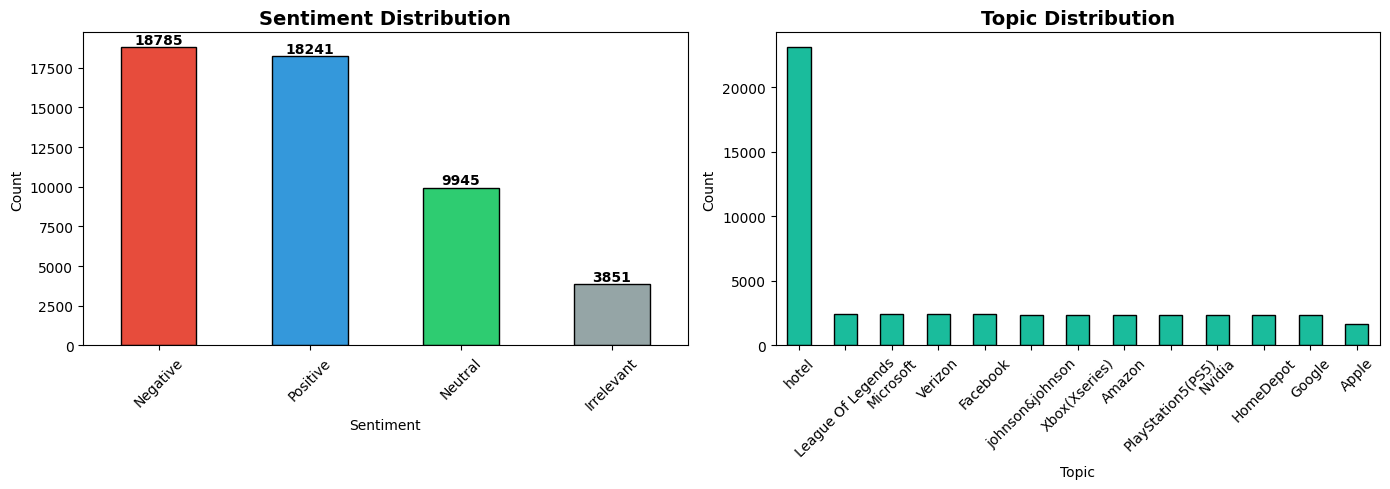

Saved: eda_distribution.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment bar chart
colors_sent = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']
ax1 = axes[0]
df['sentiment'].value_counts().plot(kind='bar', ax=ax1, color=colors_sent, edgecolor='black')
ax1.set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
for i, (val, count) in enumerate(df['sentiment'].value_counts().items()):
    ax1.text(i, count + 200, str(count), ha='center', fontweight='bold')

# Topic bar chart
ax2 = axes[1]
df['topic'].value_counts().plot(kind='bar', ax=ax2, color='#1abc9c', edgecolor='black')
ax2.set_title('Topic Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Topic')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_distribution.png")

---
## 🧹 Step 2: Preprocessing

### 2.1 Filter: Keep only Positive / Neutral / Negative

In [22]:
print(f"Before filtering: {len(df)} rows")
df = df[df['sentiment'].isin(['Positive', 'Neutral', 'Negative'])].copy()
print(f"After removing 'Irrelevant': {len(df)} rows")

# --- Drop nulls in text/sentiment ---
df.dropna(subset=['text', 'sentiment'], inplace=True)
print(f"After dropping nulls: {len(df)} rows")

Before filtering: 50822 rows
After removing 'Irrelevant': 46971 rows
After dropping nulls: 46773 rows


### 2.2 Text Cleaning Function

In [23]:
def clean_text(text):
    """Clean tweet text for model input."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # Remove URLs
    text = re.sub(r'@\w+', '', text)                     # Remove @mentions
    text = re.sub(r'#\w+', '', text)                     # Remove #hashtags
    try:
        text = contractions.fix(text)                     # Expand contractions
    except Exception:
        pass
    text = re.sub(r'[^a-zA-Z\s]', '', text)              # Keep letters & spaces only
    text = re.sub(r'\s+', ' ', text).strip()              # Strip extra whitespace
    return text

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

# Remove rows where cleaning resulted in empty string
df = df[df['clean_text'].str.len() > 0].copy()
print(f"After text cleaning: {len(df)} rows")
print(f"\nSample cleaned text:")
print(df[['text', 'clean_text']].head(3).to_string())

After text cleaning: 46661 rows

Sample cleaned text:
             text  clean_text
0  @amazon wtf .          wtf
1   @ amazon wtf.  amazon wtf
2   @ amazon wtf.  amazon wtf


### 2.2b Duplicate Check After Cleaning

The cleaning step above is aggressive (strips URLs, @mentions, #hashtags, digits, punctuation), so
different raw tweets can collapse onto the same `clean_text` string (e.g. `"@amazon wtf ."` and
`"@ amazon wtf."` both become `"amazon wtf"`). Duplicated `clean_text` rows that land on opposite
sides of the train/val/test split are a **train/test leak** — the model can "memorize" a training
duplicate instead of generalizing. Check and remove them *before* splitting.

In [24]:
# clean_text groups can be ambiguous in two ways: (1) the SAME clean_text maps to different
# sentiment labels (the aggressive cleaning discarded whatever originally distinguished them), or
# (2) the same clean_text maps to different topics. Naively keeping the first occurrence
# (keep='first') would pick a label based on row order alone, not any meaningful rule -- e.g.
# clean_text == "a" appears with Negative, Neutral AND Positive labels across 9 different topics.
# Drop those ambiguous groups entirely first, then dedupe the (now label-consistent) remainder.
dup_mask = df['clean_text'].duplicated(keep=False)
n_dup_rows = dup_mask.sum()

print(f"clean_text duplicate check:")
print(f"  Rows sharing clean_text with >=1 other row: {n_dup_rows} ({n_dup_rows/len(df)*100:.1f}%)")

if n_dup_rows > 0:
    grp = df.groupby('clean_text')
    ambiguous_sentiment = grp['sentiment'].nunique() > 1
    ambiguous_topic = grp['topic'].nunique() > 1
    ambiguous_texts = set(ambiguous_sentiment[ambiguous_sentiment].index) | set(ambiguous_topic[ambiguous_topic].index)

    print(f"  clean_text groups with >1 sentiment label: {int(ambiguous_sentiment.sum())}")
    print(f"  clean_text groups with >1 topic label:     {int(ambiguous_topic.sum())}")
    print(f"  Combined ambiguous groups (either):        {len(ambiguous_texts)}")

    ambiguous_row_mask = df['clean_text'].isin(ambiguous_texts)
    print("\nExample ambiguous groups (dropped entirely — no reliable single label):")
    print(df[ambiguous_row_mask].sort_values('clean_text')[['id', 'text', 'clean_text', 'sentiment', 'topic']].head(9).to_string())

    before = len(df)
    df = df[~ambiguous_row_mask].copy()
    n_ambiguous_dropped = before - len(df)
    print(f"\nDropped {n_ambiguous_dropped} rows belonging to an ambiguous-label clean_text group.")

    # Remaining duplicate groups are now label-consistent (same sentiment AND same topic) —
    # safe to keep just one row per group.
    before_dedup = len(df)
    df = df.drop_duplicates(subset='clean_text', keep='first').reset_index(drop=True)
    n_consistent_dropped = before_dedup - len(df)
    print(f"Dropped {n_consistent_dropped} additional duplicate rows from label-consistent groups.")
    print(f"Total dropped: {n_ambiguous_dropped + n_consistent_dropped} -> {len(df)} rows remain (was {before} going into the split).")
else:
    print("\nNo duplicates found — dataset unchanged.")

# --- Export the final filtered + deduplicated id list (reproducibility artifact, see Step 10) ---
os.makedirs('./artifacts', exist_ok=True)
df[['id']].to_csv('./artifacts/filtered_ids.csv', index=False)
print(f"Saved {len(df)} ids used for train/val/test splitting -> ./artifacts/filtered_ids.csv")

clean_text duplicate check:
  Rows sharing clean_text with >=1 other row: 3417 (7.3%)
  clean_text groups with >1 sentiment label: 55
  clean_text groups with >1 topic label:     93
  Combined ambiguous groups (either):        97

Example ambiguous groups (dropped entirely — no reliable single label):
          id       text clean_text sentiment              topic
3263    3263          a          a   Neutral      Xbox(Xseries)
20492  20492  Awwww....          a  Positive           Facebook
20491  20491  Awwww....          a  Positive           Facebook
20490  20490  Awwww....          a  Positive           Facebook
20015  20015          a          a  Positive           Facebook
20493  20493  Awwww....          a  Positive           Facebook
7885    7885    Awwwww.          a  Negative             Google
773      773          a          a  Negative             Amazon
11159  11159          a          a  Positive  League Of Legends

Dropped 778 rows belonging to an ambiguous-label clean_t

### 2.2c Cleaning Variant — "Light" Cleaning (keeps digits & hashtag words)

`clean_text()` above strips `#hashtags` down to nothing and removes every digit, but tokens like
`#fail` or `10/10` can carry real sentiment signal. Define a lighter variant that only strips the
`#` character (keeping the word underneath) and keeps digits, so the two variants can be compared
head-to-head later as TF-IDF + Logistic Regression baselines (Step 6.5, Baseline E) to quantify the
accuracy delta this cleaning choice costs.

In [25]:
def clean_text_light(text):
    """Lighter cleaning: strip URLs/mentions, unwrap '#tag' -> 'tag', keep digits and letters."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # Remove URLs
    text = re.sub(r'@\w+', '', text)                     # Remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)                 # Unwrap hashtags: '#fail' -> 'fail'
    try:
        text = contractions.fix(text)
    except Exception:
        pass
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)            # Keep letters, digits & spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text_light'] = df['text'].apply(clean_text_light)
n_empty_light = (df['clean_text_light'].str.len() == 0).sum()
n_dup_light = df['clean_text_light'].duplicated().sum()
print(f"Light cleaning: {n_empty_light} rows become empty, {n_dup_light} duplicate clean_text_light rows.")
print(f"(Main cleaning already dropped all empty/duplicate rows above, so this doesn't drop rows here —\n"
      f" it's used purely as an alternate feature column for the Baseline E delta comparison in Step 6.5.)")

print("\nSample: main clean_text vs clean_text_light")
print(df[['text', 'clean_text', 'clean_text_light']].sample(5, random_state=SEED).to_string())

Light cleaning: 0 rows become empty, 0 duplicate clean_text_light rows.
(Main cleaning already dropped all empty/duplicate rows above, so this doesn't drop rows here —
 it's used purely as an alternate feature column for the Baseline E delta comparison in Step 6.5.)

Sample: main clean_text vs clean_text_light
                                                                                                                                                                               text                                                                                                                                                                clean_text                                                                                                                                                          clean_text_light
35985                                                                                                                                             The breakfast was very

### 2.3 Label Encoding

In [26]:
sentiment_encoder = LabelEncoder()
df['sentiment_encoded'] = sentiment_encoder.fit_transform(df['sentiment'])
print(f"\nSentiment classes: {sentiment_encoder.classes_.tolist()}")
print(f"Encoded mapping: {dict(zip(sentiment_encoder.classes_, sentiment_encoder.transform(sentiment_encoder.classes_)))}")

topic_encoder = LabelEncoder()
df['topic_encoded'] = topic_encoder.fit_transform(df['topic'])
print(f"\nTopic classes ({len(topic_encoder.classes_)}): {topic_encoder.classes_.tolist()}")


Sentiment classes: ['Negative', 'Neutral', 'Positive']
Encoded mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}

Topic classes (13): ['Amazon', 'Apple', 'Facebook', 'Google', 'HomeDepot', 'League Of Legends', 'Microsoft', 'Nvidia', 'PlayStation5(PS5)', 'Verizon', 'Xbox(Xseries)', 'hotel', 'johnson&johnson']


### 2.4 Train / Val / Test Split (70 / 15 / 15)

In [27]:
X_text = df['clean_text'].values
X_raw_text = df['text'].values
y_sentiment = df['sentiment_encoded'].values
topic_ids = df['topic_encoded'].values

# First split: 70% train, 30% temp
X_train_text, X_temp_text, X_train_raw, X_temp_raw, y_train, y_temp, topic_train, topic_temp = train_test_split(
    X_text, X_raw_text, y_sentiment, topic_ids,
    test_size=0.30, stratify=y_sentiment, random_state=SEED
)

# Second split: 50/50 of temp → 15% val, 15% test
X_val_text, X_test_text, X_val_raw, X_test_raw, y_val, y_test, topic_val, topic_test = train_test_split(
    X_temp_text, X_temp_raw, y_temp, topic_temp,
    test_size=0.50, stratify=y_temp, random_state=SEED
)

# X_*_raw carries the original (uncleaned) tweet text, aligned index-for-index with the
# corresponding clean-text/label/topic arrays — needed for the zero-shot RoBERTa baseline
# (Step 6.5) and the counterfactual flip-rate experiment (Step 9.3), both of which need the
# raw tweet rather than the aggressively-cleaned text.

### 2.5 Split Summary

In [28]:
for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"\n{name} set: {len(y_split)} samples")
    for cls_idx, cls_name in enumerate(sentiment_encoder.classes_):
        count = (y_split == cls_idx).sum()
        print(f"  {cls_name}: {count} ({count/len(y_split)*100:.1f}%)")


Train set: 31077 samples
  Negative: 12601 (40.5%)
  Neutral: 6369 (20.5%)
  Positive: 12107 (39.0%)

Val set: 6659 samples
  Negative: 2700 (40.5%)
  Neutral: 1365 (20.5%)
  Positive: 2594 (39.0%)

Test set: 6660 samples
  Negative: 2700 (40.5%)
  Neutral: 1365 (20.5%)
  Positive: 2595 (39.0%)


---
## 🤖 Step 3: RoBERTa Embedding Extraction & TensorFlow Dataset

### 3.1 Load RoBERTa Tokenizer & Model (PyTorch)

In [29]:
MODEL_NAME = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
roberta_model = AutoModel.from_pretrained(MODEL_NAME)
roberta_model.to(DEVICE)
roberta_model.eval()  # Inference mode — no gradient needed
print(f"Loaded PyTorch model: {MODEL_NAME}")
print(f"Model on device: {next(roberta_model.parameters()).device}")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                        | Status     |  | 
---------------------------+------------+--+-
classifier.dense.weight    | UNEXPECTED |  | 
classifier.out_proj.bias   | UNEXPECTED |  | 
classifier.out_proj.weight | UNEXPECTED |  | 
classifier.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded PyTorch model: cardiffnlp/twitter-roberta-base-sentiment-latest
Model on device: cuda:0


### 3.2 Mean Pooling & Batch Extraction Function

In [30]:
MAX_LEN = 128
EMBED_BATCH_SIZE = 64  # Batch size for embedding extraction (no gradients → can be larger)

def mean_pooling(last_hidden_state, attention_mask):
    """
    Mean pooling: average all token embeddings weighted by attention_mask.
    Much better than [CLS]-only — captures full sentence context.
    """
    # attention_mask: (batch, seq_len) → expand to (batch, seq_len, hidden_dim)
    mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    sum_embeddings = torch.sum(last_hidden_state * mask_expanded, dim=1)
    sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask

def extract_embeddings(texts, batch_size=EMBED_BATCH_SIZE):
    """
    Extract mean-pooled embeddings from RoBERTa using PyTorch.
    Returns numpy array of shape (N, 768).
    """
    all_embeddings = []
    total = len(texts)

    for i in range(0, total, batch_size):
        batch_texts = texts[i:i+batch_size].tolist()

        # Tokenize batch
        encoding = tokenizer(
            batch_texts,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Move to GPU if available
        input_ids = encoding['input_ids'].to(DEVICE)
        attention_mask = encoding['attention_mask'].to(DEVICE)

        # Forward pass — no gradients needed for feature extraction
        with torch.no_grad():
            outputs = roberta_model(input_ids=input_ids, attention_mask=attention_mask)

        # Mean pooling over all tokens (weighted by attention mask)
        embeddings = mean_pooling(outputs.last_hidden_state, attention_mask).cpu().numpy()
        all_embeddings.append(embeddings)

        if (i // batch_size) % 20 == 0:
            print(f"  Processed {min(i+batch_size, total)}/{total} texts...")

    return np.concatenate(all_embeddings, axis=0)

### 3.3 Extract Embeddings for All Splits

In [31]:
print("\n--- Extracting Train embeddings (mean pooling) ---")
train_embeddings = extract_embeddings(X_train_text)
print(f"Train embeddings shape: {train_embeddings.shape}")

print("\n--- Extracting Val embeddings (mean pooling) ---")
val_embeddings = extract_embeddings(X_val_text)
print(f"Val embeddings shape: {val_embeddings.shape}")

print("\n--- Extracting Test embeddings (mean pooling) ---")
test_embeddings = extract_embeddings(X_test_text)
print(f"Test embeddings shape: {test_embeddings.shape}")

# Free GPU memory after extraction
del roberta_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\n Embeddings extracted! RoBERTa model freed from GPU.")


--- Extracting Train embeddings (mean pooling) ---


model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

  Processed 64/31077 texts...
  Processed 1344/31077 texts...
  Processed 2624/31077 texts...
  Processed 3904/31077 texts...
  Processed 5184/31077 texts...
  Processed 6464/31077 texts...
  Processed 7744/31077 texts...
  Processed 9024/31077 texts...
  Processed 10304/31077 texts...
  Processed 11584/31077 texts...
  Processed 12864/31077 texts...
  Processed 14144/31077 texts...
  Processed 15424/31077 texts...
  Processed 16704/31077 texts...
  Processed 17984/31077 texts...
  Processed 19264/31077 texts...
  Processed 20544/31077 texts...
  Processed 21824/31077 texts...
  Processed 23104/31077 texts...
  Processed 24384/31077 texts...
  Processed 25664/31077 texts...
  Processed 26944/31077 texts...
  Processed 28224/31077 texts...
  Processed 29504/31077 texts...
  Processed 30784/31077 texts...
Train embeddings shape: (31077, 768)

--- Extracting Val embeddings (mean pooling) ---
  Processed 64/6659 texts...
  Processed 1344/6659 texts...
  Processed 2624/6659 texts...
  Proce

### 3.4 Auto Topic Classifier (feeds the main model — not the ground-truth topic)

Train a topic classifier — TF-IDF (on `clean_text`) + Logistic Regression, with vocabulary size and
regularization strength `C` chosen by 5-fold cross-validation — *before* building the main model.
Its **predicted** topic — not the dataset's ground-truth `topic` column — is what gets fed into the
dual-input model's `topic_id` input from here on (the Step 3.5 TF Datasets below, Step 4's model,
Step 6.5's Baseline C, and Step 7's inference demo). This matches real deployment, where the true
topic isn't available and has to be predicted from the tweet itself, and it means the main model is
trained on the same (imperfect) topic signal it will actually see at inference time, instead of a
ground-truth label it will never get outside of this dataset.

An earlier version of this classifier used the RoBERTa sentiment embeddings as features and could
not close the train/val gap without losing val/test accuracy — those embeddings come from a
sentiment-tuned checkpoint, so topic signal was diluted across all 768 dims. Topic in this dataset
is overwhelmingly lexical (brand names appear verbatim in the tweets), so TF-IDF on the tweet text
itself gives the classifier a far more direct, task-relevant signal.


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.utils import shuffle

# Shuffle the training rows (text + topic labels stay paired) before cross-validation.
X_train_text_shuf, topic_train_shuf = shuffle(X_train_text, topic_train, random_state=SEED)

# Switched from RoBERTa-embedding features to TF-IDF: the embeddings come from a SENTIMENT-tuned
# checkpoint, so topic signal was entangled/diluted across all 768 dims, and no amount of
# regularization on that representation could close the train/val gap without also losing val/test
# accuracy (see the earlier attempts in this cell's history). Topic in this dataset is
# overwhelmingly lexical — brand names ("amazon", "xbox", "playstation", "google", ...) appear
# verbatim in the tweets — so TF-IDF on `clean_text` gives the classifier a far more direct,
# task-relevant signal to work with, instead of trying to disentangle it from sentiment features.
topic_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)),
])

param_grid = {
    'tfidf__max_features': [5000, 10000, 20000],
    'clf__C': [0.1, 1.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid = GridSearchCV(topic_pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_text_shuf, topic_train_shuf)

topic_clf = grid.best_estimator_
print(f"Best params: {grid.best_params_}  (5-fold CV accuracy: {grid.best_score_:.4f})")

topic_train_pred = topic_clf.predict(X_train_text)
topic_val_pred = topic_clf.predict(X_val_text)
topic_test_pred = topic_clf.predict(X_test_text)

print(f"Topic classifier — Train accuracy: {accuracy_score(topic_train, topic_train_pred):.4f}")
print(f"Topic classifier — Val accuracy:   {accuracy_score(topic_val, topic_val_pred):.4f}")
print(f"Topic classifier — Test accuracy:  {accuracy_score(topic_test, topic_test_pred):.4f}")
print(f"Topic classifier — Test macro-F1:  {f1_score(topic_test, topic_test_pred, average='macro'):.4f}")


def predict_topic_from_text(cleaned_text):
    """cleaned_text: already clean_text()-ed tweet string -> predicted topic string."""
    topic_id_pred = topic_clf.predict([cleaned_text])[0]
    return topic_encoder.inverse_transform([topic_id_pred])[0]


Best params: {'clf__C': 10.0, 'tfidf__max_features': 20000}  (5-fold CV accuracy: 0.9490)
Topic classifier — Train accuracy: 0.9946
Topic classifier — Val accuracy:   0.9513
Topic classifier — Test accuracy:  0.9544
Topic classifier — Test macro-F1:  0.9212


### 3.5 Create TensorFlow Datasets

In [33]:
BATCH_TRAIN = 16
BATCH_EVAL = 32
BUFFER_SIZE = 1000

def make_tf_dataset(embeddings, topic_ids, labels, batch_size, shuffle=False):
    """Create a tf.data.Dataset with pre-extracted embeddings + topic input."""
    dataset = tf.data.Dataset.from_tensor_slices((
        {
            'text_embedding': embeddings.astype(np.float32),
            'topic_id': topic_ids.reshape(-1, 1)
        },
        labels
    ))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=BUFFER_SIZE, seed=SEED)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# Use the AUTO-PREDICTED topic (Step 3.5) as the model's topic_id input, not the ground-truth
# dataset topic — this makes the main model's training input match real inference, where the
# true topic isn't available and must be predicted from the tweet's own embedding.
train_ds = make_tf_dataset(train_embeddings, topic_train_pred, y_train, BATCH_TRAIN, shuffle=True)
val_ds   = make_tf_dataset(val_embeddings, topic_val_pred, y_val, BATCH_EVAL)
test_ds  = make_tf_dataset(test_embeddings, topic_test_pred, y_test, BATCH_EVAL)

# Quick check
for batch_x, batch_y in train_ds.take(1):
    print(f"Batch text_embedding shape: {batch_x['text_embedding'].shape}")
    print(f"Batch topic_id shape: {batch_x['topic_id'].shape}")
    print(f"Batch labels shape: {batch_y.shape}")
    break

print("\n TF Datasets created successfully!")

Batch text_embedding shape: (16, 768)
Batch topic_id shape: (16, 1)
Batch labels shape: (16,)

 TF Datasets created successfully!


---
## 🏗️ Step 4: Model Architecture

In [34]:
NUM_TOPICS = len(topic_encoder.classes_)  # 12 topics
NUM_CLASSES = len(sentiment_encoder.classes_)  # 3 classes
ROBERTA_DIM = 768  # [CLS] embedding dimension
TOPIC_EMB_DIM = 32
DROPOUT_RATE = 0.4

def build_model(roberta_dim=768, num_topics=12, num_classes=3,
                topic_emb_dim=32, dropout_rate=0.4):
    """
    Improved classification head with BatchNorm + deeper architecture:
    - Text branch: RoBERTa mean-pooled embedding (768-dim) → BatchNorm → Dropout
    - Topic branch: Embedding(num_topics+1, 32) → Flatten
    - Fusion: Concatenate → Dense(512) → BN → Dropout → Dense(256) → BN → Dropout → Dense(64) → Softmax
    """
    # --- Inputs ---
    text_embedding = tf.keras.Input(shape=(roberta_dim,), dtype=tf.float32, name='text_embedding')
    topic_id       = tf.keras.Input(shape=(1,),           dtype=tf.int32,   name='topic_id')

    # --- Text branch: normalize embeddings first ---
    text_vec = tf.keras.layers.BatchNormalization(name='text_bn')(text_embedding)
    text_vec = tf.keras.layers.Dropout(dropout_rate, name='text_dropout')(text_vec)

    # --- Topic branch ---
    topic_vec = tf.keras.layers.Embedding(
        input_dim=num_topics + 1,
        output_dim=topic_emb_dim,
        name='topic_embedding'
    )(topic_id)
    topic_vec = tf.keras.layers.Flatten(name='topic_flatten')(topic_vec)

    # --- Fusion: deeper head with BatchNorm for better gradient flow ---
    combined = tf.keras.layers.Concatenate(name='fusion')([text_vec, topic_vec])
    x = tf.keras.layers.Dense(512, activation='relu', name='dense_512')(combined)
    x = tf.keras.layers.BatchNormalization(name='bn_512')(x)
    x = tf.keras.layers.Dropout(dropout_rate, name='dropout_512')(x)
    x = tf.keras.layers.Dense(256, activation='relu', name='dense_256')(x)
    x = tf.keras.layers.Concatenate(name='skip_connection')([x, combined])  # skip connection
    x = tf.keras.layers.Dense(256, activation='relu', name='dense_256b')(x)
    x = tf.keras.layers.BatchNormalization(name='bn_256')(x)
    x = tf.keras.layers.Dropout(dropout_rate, name='dropout_256')(x)
    x = tf.keras.layers.Dense(64, activation='relu', name='dense_64')(x)
    output = tf.keras.layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = tf.keras.Model(
        inputs=[text_embedding, topic_id],
        outputs=output,
        name='RoBERTa_Topic_Sentiment'
    )
    return model

### Compile Model

- **Optimizer:** AdamW (lr=1e-3, weight_decay=0.01) — higher LR since we're training a head on frozen embeddings
- **Loss:** SparseCategoricalCrossentropy
- **Label Smoothing:** 0.1 for better generalization

In [35]:
model = build_model(ROBERTA_DIM, NUM_TOPICS, NUM_CLASSES, TOPIC_EMB_DIM, DROPOUT_RATE)

# Compile
optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=0.01)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

### Model Parameter Summary

Log the parameter count and confirm the initialization seed so a training run is reproducible
end-to-end. Dense/Embedding kernels use Keras's default `glorot_uniform` initializer, which draws
from TensorFlow's global RNG — already pinned by `tf.random.set_seed(SEED)` in the Reproducibility
Configuration cell above, so re-running `build_model()` with the same `SEED` reproduces the same
initial weights.

In [36]:
model.summary()

trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_variables])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_variables])
print(f"\nTrainable params:     {trainable_params:,}")
print(f"Non-trainable params: {non_trainable_params:,}")
print(f"Total params:          {trainable_params + non_trainable_params:,}")
print(f"Weight-init seed: SEED={SEED} (global TF seed set via tf.random.set_seed in the Reproducibility cell)")

Model: "RoBERTa_Topic_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_embedding      │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topic_id            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_bn             │ (None, 768)       │      3,072 │ text_embedding[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topic_embedding     │ (None, 1, 32)     │        448 │ topic_id[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_dropout        │ (None, 768)       │          0 │ text_bn[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topic_flatten       │ (None, 32)        │          0 │ topic_embedding[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 800)       │          0 │ text_dropout[0][… │
│ (Concatenate)       │                   │            │ topic_flatten[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_512 (Dense)   │ (None, 512)       │    410,112 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_512              │ (None, 512)       │      2,048 │ dense_512[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_512         │ (None, 512)       │          0 │ bn_512[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_256 (Dense)   │ (None, 256)       │    131,328 │ dropout_512[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_connection     │ (None, 1056)      │          0 │ dense_256[0][0],  │
│ (Concatenate)       │                   │            │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_256b (Dense)  │ (None, 256)       │    270,592 │ skip_connection[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_256              │ (None, 256)       │      1,024 │ dense_256b[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_256         │ (None, 256)       │          0 │ bn_256[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 64)        │     16,448 │ dropout_256[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        195 │ dense_64[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 835,267 (3.19 MB)

 Trainable params: 832,195 (3.17 MB)

 Non-trainable params: 3,072 (12.00 KB)


Trainable params:     832,195
Non-trainable params: 3,078
Total params:          835,273
Weight-init seed: SEED=42 (global TF seed set via tf.random.set_seed in the Reproducibility cell)


---
## 🏋️ Step 5: Training

Train the classification head with:
- **Class weights** to handle imbalanced data
- **EarlyStopping** (patience=5) to prevent overfitting
- **ReduceLROnPlateau** for adaptive learning rate
- **ModelCheckpoint** to save best weights

### 5.1 Compute Class Weights

In [37]:
class_weights_arr = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))
print(f"Class weights: {class_weight_dict}")
for idx, name in enumerate(sentiment_encoder.classes_):
    print(f"  {name} (class {idx}): weight = {class_weight_dict[idx]:.4f}")

Class weights: {0: np.float64(0.8220776128878661), 1: np.float64(1.6264719736222326), 2: np.float64(0.855620715288676)}
  Negative (class 0): weight = 0.8221
  Neutral (class 1): weight = 1.6265
  Positive (class 2): weight = 0.8556


### 5.2 Setup Callbacks

In [38]:
os.makedirs('./best_model/', exist_ok=True)

def make_callbacks(patience=5, checkpoint_path='./best_model/model.weights.h5', reduce_lr_patience=3):
    """
    Build a fresh set of callbacks. `patience` is NOT shared across every training run in this
    notebook: the full model (30-epoch budget) uses patience=5, while the 15-epoch ablation runs
    (Step 6.6) use patience=4, so early stopping keeps roughly the same relative "budget" at the
    shorter epoch cap instead of silently reusing the 30-epoch setting.
    """
    ckpt_dir = os.path.dirname(checkpoint_path)
    if ckpt_dir:
        os.makedirs(ckpt_dir, exist_ok=True)
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=reduce_lr_patience,
            verbose=1,
            min_lr=1e-6
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        )
    ]

# Full model: 30-epoch budget -> patience=5 (see docstring above)
callbacks = make_callbacks(patience=5, checkpoint_path='./best_model/model.weights.h5')

### 5.3 Train the Model

In [39]:
EPOCHS = 30  # EarlyStopping will halt when needed

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\n Training complete!")

Epoch 1/30
1943/1943 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7403 - loss: 0.6965
Epoch 1: val_loss improved from None to 0.47921, saving model to ./best_model/model.weights.h5

Epoch 1: finished saving model to ./best_model/model.weights.h5
1943/1943 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.7617 - loss: 0.6120 - val_accuracy: 0.8057 - val_loss: 0.4792 - learning_rate: 0.0010
Epoch 2/30
1938/1943 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7899 - loss: 0.5439
Epoch 2: val_loss improved from 0.47921 to 0.47228, saving model to ./best_model/model.weights.h5

Epoch 2: finished saving model to ./best_model/model.weights.h5
1943/1943 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7909 - loss: 0.5357 - val_accuracy: 0.8024 - val_loss: 0.4723 - learning_rate: 0.0010
Epoch 3/30
1929/1943 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7973 - loss: 0.5174
Epoch 3: val_loss improved from 0.47228 to 0.46418, saving model to ./best_model/model.weights.h5

Epoch 3: finished saving mo

---
## 📈 Step 6: Evaluation

### 6.1 Load Best Weights & Predict

In [40]:

model.load_weights('./best_model/model.weights.h5')
print("Loaded best model weights.")

# Predict on test set
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

Loaded best model weights.
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


### 6.2 Classification Report

In [41]:
target_names = sentiment_encoder.classes_.tolist()
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

overall_acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Overall Accuracy: {overall_acc:.4f}")
print(f"Macro F1-Score:   {macro_f1:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative     0.9181    0.8756    0.8963      2700
     Neutral     0.7214    0.8630    0.7859      1365
    Positive     0.9233    0.8724    0.8972      2595

    accuracy                         0.8718      6660
   macro avg     0.8543    0.8703    0.8598      6660
weighted avg     0.8798    0.8718    0.8740      6660

Overall Accuracy: 0.8718
Macro F1-Score:   0.8598


### 6.3 Confusion Matrix

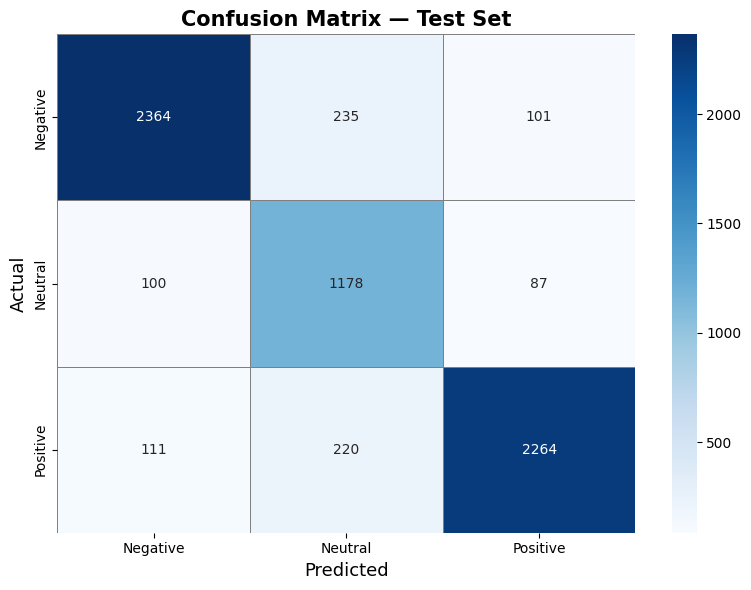

Saved: loss_figure/confusion_matrix.png


In [42]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names, yticklabels=target_names,
    linewidths=0.5, linecolor='gray', ax=ax
)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title('Confusion Matrix — Test Set', fontsize=15, fontweight='bold')
plt.tight_layout()
os.makedirs('loss_figure', exist_ok=True)
plt.savefig('loss_figure/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_figure/confusion_matrix.png")

### 6.4 Training History (Loss & Accuracy Curves)

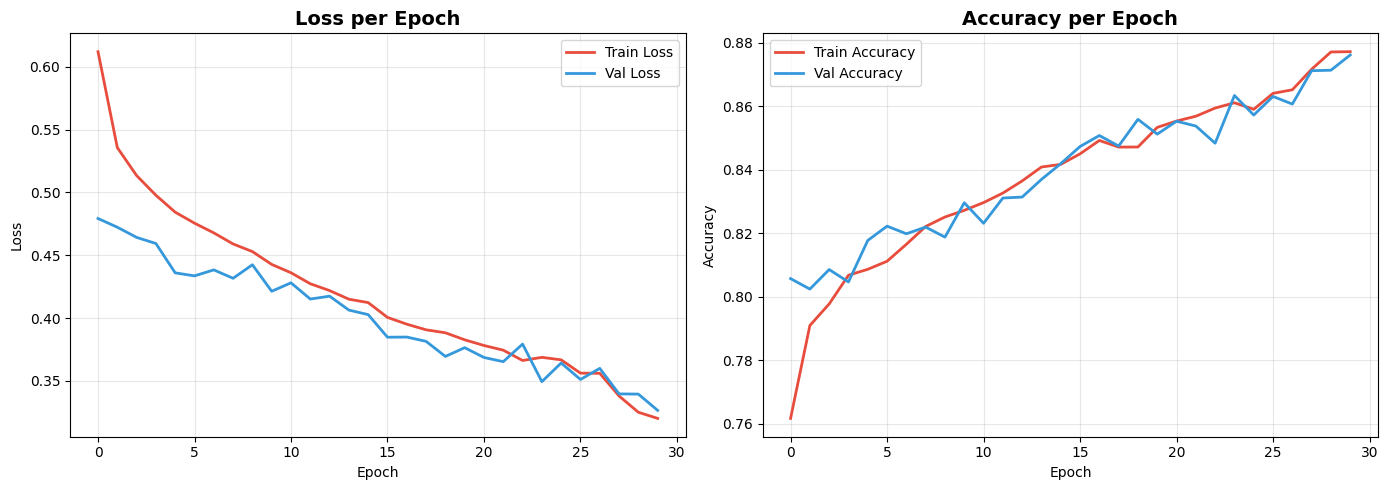

Saved: loss_figure/training_history.png


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2, color='#e74c3c')
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='#3498db')
axes[0].set_title('Loss per Epoch', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curve
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, color='#e74c3c')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, color='#3498db')
axes[1].set_title('Accuracy per Epoch', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('loss_figure/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_figure/training_history.png")

---
## 📐 Step 6.5: Baseline Comparison (Table 3)

The full model (RoBERTa embeddings + topic embedding + BatchNorm + skip-connection head) is only a
meaningful result if it is compared against baselines that either (a) use no training at all, or
(b) receive progressively more of the same input. Five points of comparison:

| # | Baseline | Text feature | Topic feature | Trained? |
|---|----------|-------------|----------------|----------|
| A | Zero-shot cardiffnlp RoBERTa head | raw tweet (model's own preprocessing) | — | No |
| B | TF-IDF + Logistic Regression | `clean_text` | — | Yes |
| C | TF-IDF + one-hot topic + Logistic Regression | `clean_text` | one-hot(12), auto-predicted (Step 3.5) | Yes |
| D | RoBERTa mean-pooled embeddings + Logistic Regression | 768-dim embedding | — | Yes (LR only) |
| E | TF-IDF (light cleaning) + Logistic Regression | `clean_text_light` | — | Yes |

Baseline **C** is the only one that receives the same (text, topic) input as the main model —
including the same auto-predicted topic, not the ground-truth label — so it is the one that actually
tests whether the Keras head's extra depth/BatchNorm/skip-connection earns its keep over a linear
model given identical features.

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.sparse import hstack

baseline_results = []

def record_baseline(name, y_true, y_pred, notes=""):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro')
    baseline_results.append({'model': name, 'accuracy': acc, 'macro_f1': f1m, 'notes': notes})
    print(f"[{name}] accuracy={acc:.4f}  macro_f1={f1m:.4f}  {notes}")
    return acc, f1m

### Baseline A — Zero-shot cardiffnlp RoBERTa Sentiment Head (no training)

Uses the pretrained classification head that ships with `cardiffnlp/twitter-roberta-base-sentiment-latest`
directly — no fine-tuning, no Keras head. This is the "for free" floor: any trained model on this
dataset should clear it by a meaningful margin. Text is preprocessed with the model card's own
convention (`@user`, `http`) rather than the notebook's aggressive `clean_text()`, since that is
what the checkpoint was tuned on.

In [45]:
# --- Baseline A: Zero-shot cardiffnlp RoBERTa sentiment head (no training) ---
from transformers import AutoModelForSequenceClassification

def roberta_card_preprocess(text):
    """cardiffnlp's own preprocessing convention (not our clean_text)."""
    if not isinstance(text, str):
        return ""
    new_tokens = []
    for tok in text.split(' '):
        tok = '@user' if tok.startswith('@') and len(tok) > 1 else tok
        tok = 'http' if tok.startswith('http') else tok
        new_tokens.append(tok)
    return ' '.join(new_tokens)

zero_shot_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
zero_shot_model.to(DEVICE)
zero_shot_model.eval()

id2label = {int(k): v.lower() for k, v in zero_shot_model.config.id2label.items()}
print(f"Zero-shot model label map: {id2label}")

zero_shot_preds = []
zs_batch_size = EMBED_BATCH_SIZE
zs_texts = [roberta_card_preprocess(t) for t in X_test_raw]

for i in range(0, len(zs_texts), zs_batch_size):
    batch = zs_texts[i:i + zs_batch_size]
    encoding = tokenizer(batch, max_length=MAX_LEN, padding='max_length', truncation=True, return_tensors='pt')
    input_ids = encoding['input_ids'].to(DEVICE)
    attention_mask = encoding['attention_mask'].to(DEVICE)
    with torch.no_grad():
        logits = zero_shot_model(input_ids=input_ids, attention_mask=attention_mask).logits
    batch_pred_ids = torch.argmax(logits, dim=1).cpu().numpy()
    zero_shot_preds.extend(batch_pred_ids)
    if (i // zs_batch_size) % 20 == 0:
        print(f"  Zero-shot inference {min(i + zs_batch_size, len(zs_texts))}/{len(zs_texts)}...")

# Map the checkpoint's own label ids -> our sentiment_encoder's label ids via the class names
zs_label_names = [id2label[p] for p in zero_shot_preds]
our_class_lookup = {c.lower(): idx for idx, c in enumerate(sentiment_encoder.classes_)}
y_pred_zero_shot = np.array([our_class_lookup[name] for name in zs_label_names])

del zero_shot_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

record_baseline('A: Zero-shot RoBERTa head', y_test, y_pred_zero_shot, notes="no training, model's own head")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Zero-shot model label map: {0: 'negative', 1: 'neutral', 2: 'positive'}
  Zero-shot inference 64/6660...
  Zero-shot inference 1344/6660...
  Zero-shot inference 2624/6660...
  Zero-shot inference 3904/6660...
  Zero-shot inference 5184/6660...
  Zero-shot inference 6464/6660...
[A: Zero-shot RoBERTa head] accuracy=0.6634  macro_f1=0.6256  no training, model's own head


(0.6633633633633633, 0.6256075159196062)

### Baseline B — TF-IDF + Logistic Regression (text only)

Classic sparse bag-of-words baseline. Fit on `clean_text` (the same text the main model's
embeddings were extracted from), no topic information.

In [46]:
# --- Baseline B: TF-IDF + Logistic Regression (text only) ---
tfidf_vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
Xtr_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
Xte_tfidf = tfidf_vectorizer.transform(X_test_text)

lr_tfidf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
lr_tfidf.fit(Xtr_tfidf, y_train)
y_pred_tfidf = lr_tfidf.predict(Xte_tfidf)

record_baseline('B: TF-IDF + LogisticRegression', y_test, y_pred_tfidf, notes=f"vocab={len(tfidf_vectorizer.vocabulary_)}")

[B: TF-IDF + LogisticRegression] accuracy=0.8595  macro_f1=0.8486  vocab=20000


(0.8594594594594595, 0.8486073528918118)

### Baseline C — TF-IDF + One-Hot Topic + Logistic Regression

The only baseline that receives **exactly the same (text, topic) input** as the main dual-input
model — including using the Step 3.5 auto-predicted topic rather than the ground-truth label. If the
deep head in Step 4 doesn't beat this by a clear margin, the extra architecture isn't earning its
complexity.

In [47]:
# --- Baseline C: TF-IDF + One-Hot Topic + Logistic Regression ---
# Uses topic_*_pred (Step 3.5), the same auto-predicted topic the main model is trained on —
# not the ground-truth topic — so this stays a fair "same input as the main model" comparison.
topic_ohe = OneHotEncoder(handle_unknown='ignore')
topic_train_oh = topic_ohe.fit_transform(topic_train_pred.reshape(-1, 1))
topic_test_oh = topic_ohe.transform(topic_test_pred.reshape(-1, 1))

Xtr_combined = hstack([Xtr_tfidf, topic_train_oh])
Xte_combined = hstack([Xte_tfidf, topic_test_oh])

lr_combined = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
lr_combined.fit(Xtr_combined, y_train)
y_pred_combined = lr_combined.predict(Xte_combined)

record_baseline('C: TF-IDF + topic one-hot + LogisticRegression', y_test, y_pred_combined,
                notes="same (text, predicted-topic) input as the main model")

[C: TF-IDF + topic one-hot + LogisticRegression] accuracy=0.8547  macro_f1=0.8443  same (text, predicted-topic) input as the main model


(0.8546546546546546, 0.8443137149805174)

### Baseline D — RoBERTa Embeddings + Logistic Regression

Uses the exact same 768-dim mean-pooled embeddings extracted in Step 3 (no topic), fed to a linear
classifier instead of the Keras head. `StandardScaler` + `max_iter=2000` are required — the default
`lbfgs` solver at `max_iter=100` does not reliably converge on 768-dimensional dense features.


In [48]:
# --- Baseline D: RoBERTa Embeddings + Logistic Regression ---
emb_scaler = StandardScaler()
Xtr_emb_scaled = emb_scaler.fit_transform(train_embeddings)
Xte_emb_scaled = emb_scaler.transform(test_embeddings)

lr_emb = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)
lr_emb.fit(Xtr_emb_scaled, y_train)
y_pred_emb = lr_emb.predict(Xte_emb_scaled)

record_baseline('D: RoBERTa embeddings + LogisticRegression', y_test, y_pred_emb,
                notes="StandardScaler + max_iter=2000 to ensure convergence")


[D: RoBERTa embeddings + LogisticRegression] accuracy=0.8116  macro_f1=0.7949  StandardScaler + max_iter=2000 to ensure convergence


(0.8115615615615616, 0.7948808012391559)

### Baseline E — Cleaning Variant Delta (light cleaning vs. main cleaning)

Same TF-IDF + Logistic Regression pipeline as Baseline B, but fit on `clean_text_light` (keeps
digits and hashtag words) instead of `clean_text`. The accuracy/F1 delta versus Baseline B
quantifies how much sentiment signal the aggressive cleaning in Step 2.2 throws away.

In [49]:
# --- Baseline E: Cleaning Variant Delta (light cleaning vs. main cleaning) ---
X_light = df['clean_text_light'].values

X_train_light, X_temp_light, y_train_chk, y_temp_chk = train_test_split(
    X_light, y_sentiment, test_size=0.30, stratify=y_sentiment, random_state=SEED
)
X_val_light, X_test_light, y_val_chk, y_test_chk = train_test_split(
    X_temp_light, y_temp_chk, test_size=0.50, stratify=y_temp_chk, random_state=SEED
)
assert np.array_equal(y_train_chk, y_train) and np.array_equal(y_test_chk, y_test), \
    "Light-cleaning split does not align with the main split — cannot compare fairly."

tfidf_light = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
Xtr_light_tfidf = tfidf_light.fit_transform(X_train_light)
Xte_light_tfidf = tfidf_light.transform(X_test_light)

lr_light = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
lr_light.fit(Xtr_light_tfidf, y_train)
y_pred_light = lr_light.predict(Xte_light_tfidf)

acc_light, f1_light = record_baseline('E: TF-IDF (light cleaning) + LogisticRegression', y_test, y_pred_light,
                                       notes="keeps digits & hashtag words")

acc_b = baseline_results[1]['accuracy']  # Baseline B
f1_b = baseline_results[1]['macro_f1']
print(f"\nCleaning delta vs. Baseline B: accuracy {acc_light - acc_b:+.4f}, macro_f1 {f1_light - f1_b:+.4f}")

[E: TF-IDF (light cleaning) + LogisticRegression] accuracy=0.8601  macro_f1=0.8496  keeps digits & hashtag words

Cleaning delta vs. Baseline B: accuracy +0.0006, macro_f1 +0.0010


In [50]:
# --- Table 3 — Full Comparison Summary ---
baseline_results.append({
    'model': 'Main model (RoBERTa emb + topic + BN + skip head)',
    'accuracy': overall_acc,
    'macro_f1': macro_f1,
    'notes': 'trained head, Step 4-6'
})

baseline_table = pd.DataFrame(baseline_results).sort_values('macro_f1', ascending=False).reset_index(drop=True)
print("=" * 80)
print("TABLE 3 — Baseline & Main Model Comparison (Test Set)")
print("=" * 80)
print(baseline_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
baseline_table.to_csv('./artifacts/baseline_comparison_table3.csv', index=False)
print("\nSaved: ./artifacts/baseline_comparison_table3.csv")

TABLE 3 — Baseline & Main Model Comparison (Test Set)
                                            model  accuracy  macro_f1                                                notes
Main model (RoBERTa emb + topic + BN + skip head)    0.8718    0.8598                               trained head, Step 4-6
  E: TF-IDF (light cleaning) + LogisticRegression    0.8601    0.8496                         keeps digits & hashtag words
                   B: TF-IDF + LogisticRegression    0.8595    0.8486                                          vocab=20000
   C: TF-IDF + topic one-hot + LogisticRegression    0.8547    0.8443 same (text, predicted-topic) input as the main model
       D: RoBERTa embeddings + LogisticRegression    0.8116    0.7949 StandardScaler + max_iter=2000 to ensure convergence
                        A: Zero-shot RoBERTa head    0.6634    0.6256                        no training, model's own head

Saved: ./artifacts/baseline_comparison_table3.csv


---
## 🧪 Step 6.6: Ablation Study — Topic Branch / Skip Connection / BatchNorm

Four architecture variants, each trained fresh at two epoch budgets (15 and 30) across 5 random
seeds, to report **mean ± std** test accuracy / macro-F1 per (variant, epoch-budget) cell instead
of a single-run number. This is what actually lets us claim which component matters most — a single
training run cannot distinguish "this component helps" from "this particular seed got lucky."

⚠️ **Runtime note:** this is 4 variants × 2 epoch budgets × 5 seeds = 40 training runs (each fast —
head-only training on cached embeddings, no RoBERTa forward pass). Reduce `N_SEEDS` below for a
quick smoke test.

In [51]:
def build_model_ablation(variant='full', roberta_dim=768, num_topics=12, num_classes=3,
                          topic_emb_dim=32, dropout_rate=0.4):
    """
    variant:
      'full'      - topic branch + skip connection + BatchNorm (identical to build_model())
      'no_topic'  - topic embedding output is multiplied by 0 before fusion (kept in the graph so
                    the model still accepts the same {'text_embedding','topic_id'} input dict, but
                    contributes nothing to the forward pass and receives zero gradient)
      'no_skip'   - remove the skip connection (concat[x, combined] -> just x)
      'no_bn'     - remove all BatchNormalization layers
    """
    assert variant in ('full', 'no_topic', 'no_skip', 'no_bn')
    use_topic = variant != 'no_topic'
    use_skip = variant != 'no_skip'
    use_bn = variant != 'no_bn'

    text_embedding = tf.keras.Input(shape=(roberta_dim,), dtype=tf.float32, name='text_embedding')
    topic_id = tf.keras.Input(shape=(1,), dtype=tf.int32, name='topic_id')

    text_vec = tf.keras.layers.BatchNormalization(name='text_bn')(text_embedding) if use_bn else text_embedding
    text_vec = tf.keras.layers.Dropout(dropout_rate, name='text_dropout')(text_vec)

    topic_vec = tf.keras.layers.Embedding(input_dim=num_topics + 1, output_dim=topic_emb_dim,
                                           name='topic_embedding')(topic_id)
    topic_vec = tf.keras.layers.Flatten(name='topic_flatten')(topic_vec)
    if not use_topic:
        topic_vec = tf.keras.layers.Lambda(lambda t: t * 0.0, name='topic_zero_gate')(topic_vec)

    combined = tf.keras.layers.Concatenate(name='fusion')([text_vec, topic_vec])
    x = tf.keras.layers.Dense(512, activation='relu', name='dense_512')(combined)
    x = tf.keras.layers.BatchNormalization(name='bn_512')(x) if use_bn else x
    x = tf.keras.layers.Dropout(dropout_rate, name='dropout_512')(x)
    x = tf.keras.layers.Dense(256, activation='relu', name='dense_256')(x)
    if use_skip:
        x = tf.keras.layers.Concatenate(name='skip_connection')([x, combined])
    x = tf.keras.layers.Dense(256, activation='relu', name='dense_256b')(x)
    x = tf.keras.layers.BatchNormalization(name='bn_256')(x) if use_bn else x
    x = tf.keras.layers.Dropout(dropout_rate, name='dropout_256')(x)
    x = tf.keras.layers.Dense(64, activation='relu', name='dense_64')(x)
    output = tf.keras.layers.Dense(num_classes, activation='softmax', name='output')(x)

    return tf.keras.Model(inputs=[text_embedding, topic_id], outputs=output, name=f'Ablation_{variant}')

In [52]:
# --- Ablation Runner (multi-seed, multi-epoch-budget) ---
ABLATION_VARIANTS = ['full', 'no_topic', 'no_skip', 'no_bn']
EPOCH_BUDGETS = [15, 30]
N_SEEDS = 5  # reduce to 1-2 for a quick smoke test

ablation_rows = []
ablation_ckpt_dir = './ablation_ckpt'
os.makedirs(ablation_ckpt_dir, exist_ok=True)

for variant in ABLATION_VARIANTS:
    for epochs in EPOCH_BUDGETS:
        patience = 4 if epochs == 15 else 5  # shorter budget -> proportionally shorter patience
        for seed in range(N_SEEDS):
            tf.random.set_seed(seed)
            np.random.seed(seed)

            run_model = build_model_ablation(variant, ROBERTA_DIM, NUM_TOPICS, NUM_CLASSES, TOPIC_EMB_DIM, DROPOUT_RATE)
            run_model.compile(
                optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=0.01),
                loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                metrics=['accuracy']
            )

            ckpt_path = f'{ablation_ckpt_dir}/{variant}_ep{epochs}_seed{seed}.weights.h5'
            run_callbacks = make_callbacks(patience=patience, checkpoint_path=ckpt_path)

            run_model.fit(
                train_ds, validation_data=val_ds, epochs=epochs,
                class_weight=class_weight_dict, callbacks=run_callbacks, verbose=0
            )
            run_model.load_weights(ckpt_path)

            y_probs = run_model.predict(test_ds, verbose=0)
            y_hat = np.argmax(y_probs, axis=1)
            acc = accuracy_score(y_test, y_hat)
            f1m = f1_score(y_test, y_hat, average='macro')

            ablation_rows.append({'variant': variant, 'epochs': epochs, 'seed': seed,
                                   'accuracy': acc, 'macro_f1': f1m})
            print(f"[{variant} | epochs={epochs} | seed={seed}] acc={acc:.4f} macro_f1={f1m:.4f}")

            del run_model
            tf.keras.backend.clear_session()

# Restore the global seed for anything that runs after the ablation study
tf.random.set_seed(SEED)
np.random.seed(SEED)

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv('./artifacts/ablation_raw_results.csv', index=False)
print(f"\nSaved {len(ablation_df)} raw ablation runs -> ./artifacts/ablation_raw_results.csv")


Epoch 1: val_loss improved from None to 0.50812, saving model to ./ablation_ckpt/full_ep15_seed0.weights.h5

Epoch 1: finished saving model to ./ablation_ckpt/full_ep15_seed0.weights.h5

Epoch 2: val_loss did not improve from 0.50812

Epoch 3: val_loss improved from 0.50812 to 0.46261, saving model to ./ablation_ckpt/full_ep15_seed0.weights.h5

Epoch 3: finished saving model to ./ablation_ckpt/full_ep15_seed0.weights.h5

Epoch 4: val_loss did not improve from 0.46261

Epoch 5: val_loss improved from 0.46261 to 0.46241, saving model to ./ablation_ckpt/full_ep15_seed0.weights.h5

Epoch 5: finished saving model to ./ablation_ckpt/full_ep15_seed0.weights.h5

Epoch 6: val_loss did not improve from 0.46241

Epoch 7: val_loss improved from 0.46241 to 0.42117, saving model to ./ablation_ckpt/full_ep15_seed0.weights.h5

Epoch 7: finished saving model to ./ablation_ckpt/full_ep15_seed0.weights.h5

Epoch 8: val_loss did not improve from 0.42117

Epoch 9: val_loss did not improve from 0.42117

Ep

In [53]:
# --- Ablation Results — Mean ± Std by Variant ---
ablation_summary = ablation_df.groupby(['variant', 'epochs']).agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
    macro_f1_mean=('macro_f1', 'mean'), macro_f1_std=('macro_f1', 'std'),
).reset_index()

print("=" * 90)
print(f"ABLATION SUMMARY (mean ± std over {N_SEEDS} seeds)")
print("=" * 90)
for _, row in ablation_summary.iterrows():
    print(f"  {row['variant']:>10s} | epochs={int(row['epochs']):>2d} | "
          f"acc = {row['accuracy_mean']:.4f} ± {row['accuracy_std']:.4f} | "
          f"macro_f1 = {row['macro_f1_mean']:.4f} ± {row['macro_f1_std']:.4f}")

ablation_summary.to_csv('./artifacts/ablation_summary_table.csv', index=False)

# Rank components by how much macro_f1 drops relative to 'full' at the same epoch budget
print("\nComponent impact (drop in mean macro_f1 vs. 'full', at epochs=30):")
full_f1 = ablation_summary.query("variant == 'full' and epochs == 30")['macro_f1_mean'].iloc[0]
impact = (
    ablation_summary.query("epochs == 30 and variant != 'full'")
    .assign(drop_vs_full=lambda d: full_f1 - d['macro_f1_mean'])
    .sort_values('drop_vs_full', ascending=False)
)
print(impact[['variant', 'macro_f1_mean', 'drop_vs_full']].to_string(index=False))
print("\nSaved: ./artifacts/ablation_summary_table.csv")

ABLATION SUMMARY (mean ± std over 5 seeds)
        full | epochs=15 | acc = 0.8443 ± 0.0043 | macro_f1 = 0.8299 ± 0.0043
        full | epochs=30 | acc = 0.8685 ± 0.0051 | macro_f1 = 0.8558 ± 0.0055
       no_bn | epochs=15 | acc = 0.8306 ± 0.0043 | macro_f1 = 0.8152 ± 0.0041
       no_bn | epochs=30 | acc = 0.8486 ± 0.0027 | macro_f1 = 0.8343 ± 0.0027
     no_skip | epochs=15 | acc = 0.8447 ± 0.0051 | macro_f1 = 0.8293 ± 0.0054
     no_skip | epochs=30 | acc = 0.8687 ± 0.0040 | macro_f1 = 0.8554 ± 0.0042
    no_topic | epochs=15 | acc = 0.8397 ± 0.0075 | macro_f1 = 0.8244 ± 0.0076
    no_topic | epochs=30 | acc = 0.8593 ± 0.0033 | macro_f1 = 0.8461 ± 0.0039

Component impact (drop in mean macro_f1 vs. 'full', at epochs=30):
 variant  macro_f1_mean  drop_vs_full
   no_bn       0.834335      0.021433
no_topic       0.846131      0.009637
 no_skip       0.855414      0.000354

Saved: ./artifacts/ablation_summary_table.csv


---
## 🔮 Step 7: Inference Demo

Reload the RoBERTa model and test with sample COVID-19 related tweets.

In [54]:
# Reload RoBERTa for inference (lightweight — only needed for single predictions)
roberta_inference = AutoModel.from_pretrained(MODEL_NAME)
roberta_inference.to(DEVICE)
roberta_inference.eval()

def predict_sentiment(text, topic_str=None):
    """
    Predict sentiment for a single tweet.

    Args:
        text (str): Tweet content
        topic_str (str, optional): Topic name. If None (default), the topic is auto-predicted
            from the tweet's own cleaned text via the Step 3.4 TF-IDF topic classifier — no manual
            topic label is required. Pass an explicit topic to override the auto-prediction.

    Returns:
        dict: {'sentiment': str, 'confidence': float, 'probabilities': dict,
               'topic': str, 'topic_source': 'auto' | 'manual'}
    """
    # Clean the input text
    cleaned = clean_text(text)

    # Tokenize & extract embedding with PyTorch — done once, shared by topic auto-prediction and
    # the sentiment head below (no need for two separate RoBERTa forward passes).
    encoding = tokenizer(
        cleaned,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(DEVICE)
    attention_mask = encoding['attention_mask'].to(DEVICE)

    with torch.no_grad():
        outputs = roberta_inference(input_ids=input_ids, attention_mask=attention_mask)
    # Use same mean pooling as training
    embedding = mean_pooling(outputs.last_hidden_state, attention_mask).cpu().numpy()  # (1, 768)

    if topic_str is None:
        topic_str = predict_topic_from_text(cleaned)
        topic_source = 'auto'
    else:
        topic_source = 'manual'

    # Encode topic
    try:
        topic_id = topic_encoder.transform([topic_str])[0]
    except ValueError:
        print(f"  Unknown topic '{topic_str}'. Using index 0 as fallback.")
        topic_id = 0

    # Predict with Keras model
    inputs = {
        'text_embedding': embedding.astype(np.float32),
        'topic_id': np.array([[topic_id]], dtype=np.int32)
    }

    probs = model.predict(inputs, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_label = sentiment_encoder.inverse_transform([pred_idx])[0]

    # Build probabilities dict
    prob_dict = {
        sentiment_encoder.classes_[i]: float(probs[i])
        for i in range(len(sentiment_encoder.classes_))
    }

    return {
        'sentiment': pred_label,
        'confidence': float(probs[pred_idx]),
        'probabilities': prob_dict,
        'topic': topic_str,
        'topic_source': topic_source,
    }


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                        | Status     |  | 
---------------------------+------------+--+-
classifier.dense.weight    | UNEXPECTED |  | 
classifier.out_proj.bias   | UNEXPECTED |  | 
classifier.out_proj.weight | UNEXPECTED |  | 
classifier.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 🧪 Test Examples

In [55]:
test_examples = [
    "Another patch, another broken champion ruining ranked. The balance team actually has no idea what they are doing. Vanguard keeps crashing my PC and cost me 50 LP today. Im so done with this game 🤬 #LeagueOfLegends",
]

print("=" * 70)
print("Test examples (topic is auto-predicted — Step 6.7 — not supplied manually)")
print("=" * 70)

for i, text in enumerate(test_examples, 1):
    result = predict_sentiment(text)  # topic_str=None -> auto-predicted, then fed into the sentiment head
    print(f"\n--- Example {i} ---")
    print(f"  Text:            {text}")
    print(f"  Predicted topic: {result['topic']} (source: {result['topic_source']})")
    print(f"  Prediction:      {result['sentiment']} (confidence: {result['confidence']:.4f})")
    print(f"  Probs:           {', '.join(f'{k}: {v:.4f}' for k, v in result['probabilities'].items())}")

print("\n Pipeline complete!")

Test examples (topic is auto-predicted — Step 6.7 — not supplied manually)

--- Example 1 ---
  Text:            Another patch, another broken champion ruining ranked. The balance team actually has no idea what they are doing. Vanguard keeps crashing my PC and cost me 50 LP today. Im so done with this game 🤬 #LeagueOfLegends
  Predicted topic: League Of Legends (source: auto)
  Prediction:      Negative (confidence: 0.8324)
  Probs:           Negative: 0.8324, Neutral: 0.1213, Positive: 0.0463

 Pipeline complete!


---
## 🔍 Step 8: LIME-based Token Attribution

In [58]:
# --- 8.1 LIME-compatible prediction wrapper ---
from lime.lime_text import LimeTextExplainer

def make_lime_predict_fn(topic_str):
    """
    Factory: returns a LIME-compatible predict function for a given topic.

    The returned function: list[str] → np.ndarray of shape (N, 3) probabilities.
    It re-embeds each perturbed text through the full pipeline.
    """
    # Encode topic once
    try:
        tid = topic_encoder.transform([topic_str])[0]
    except ValueError:
        tid = 0

    def predict_fn(texts):
        # Clean all texts
        cleaned = [clean_text(t) for t in texts]
        # Handle empty strings after cleaning
        cleaned = [t if len(t) > 0 else "empty" for t in cleaned]

        # Tokenize batch with RoBERTa
        encoding = tokenizer(
            cleaned,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].to(DEVICE)
        attention_mask = encoding['attention_mask'].to(DEVICE)

        # Extract mean-pooled embeddings
        with torch.no_grad():
            outputs = roberta_inference(input_ids=input_ids, attention_mask=attention_mask)
        embeddings = mean_pooling(outputs.last_hidden_state, attention_mask).cpu().numpy()

        # Predict with Keras model
        batch_size = len(texts)
        inputs = {
            'text_embedding': embeddings.astype(np.float32),
            'topic_id': np.full((batch_size, 1), tid, dtype=np.int32)
        }
        probs = model.predict(inputs, verbose=0)
        return probs

    return predict_fn

# Initialize LIME explainer
lime_explainer = LimeTextExplainer(
    class_names=sentiment_encoder.classes_.tolist(),
    split_expression=r'\W+',
    random_state=SEED
)

print("✅ LIME explainer and wrapper ready.")

✅ LIME explainer and wrapper ready.


### 8.2 LIME Demo — Explain Individual Predictions


LIME Example 1
  Raw tweet:                                  Another patch, another broken champion ruining ranked. The balance team actually has no idea what they are doing. Vanguard keeps crashing my PC and cost me 50 LP today. Im so done with this game 🤬 #LeagueOfLegends
  Cleaned tweet (LIME explains THIS string):  another patch another broken champion ruining ranked the balance team actually has no idea what they are doing vanguard keeps crashing my pc and cost me lp today i am so done with this game
  Predicted topic: League Of Legends (source: auto)
  Prediction:      Negative (confidence: 0.8324)
  Probabilities: Negative: 0.8324, Neutral: 0.1213, Positive: 0.0463

  Top POSITIVE influence words (push toward 'Negative'):
    'crashing': +0.1050
    'ruining': +0.0959
    'done': +0.0832
    'another': +0.0684
    'my': +0.0614

  Top NEGATIVE influence words (push away from 'Negative'):
    'ranked': -0.0468
    'has': -0.0351
    'champion': -0.0347


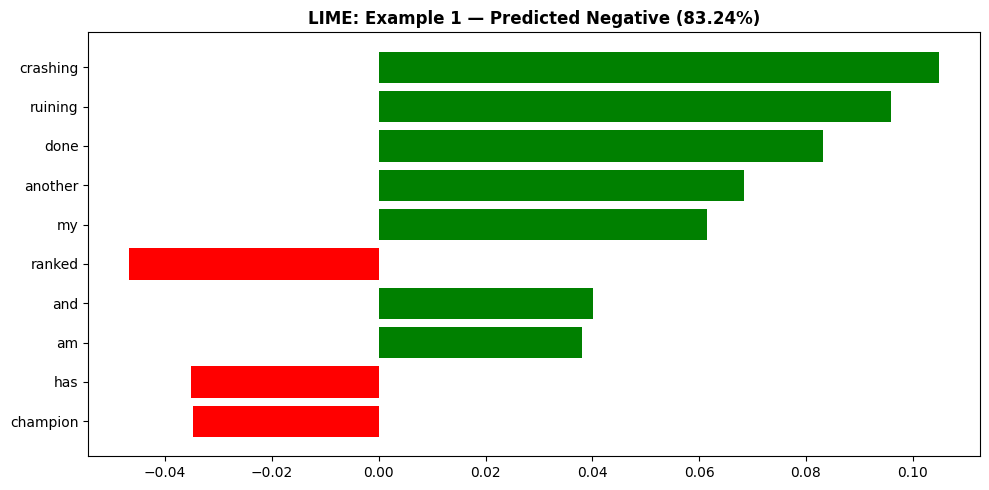


✅ LIME analysis complete for 1 tweets.


In [59]:
# --- 8.2 Run LIME on demo tweets ---
lime_demo_tweets = [
    "Another patch, another broken champion ruining ranked. The balance team actually has no idea what they are doing. Vanguard keeps crashing my PC and cost me 50 LP today. Im so done with this game 🤬 #LeagueOfLegends",
]

lime_results = []  # Store for Steps 9-11

for i, tweet in enumerate(lime_demo_tweets, 1):
    # LIME must explain the SAME string the model actually sees. predict_fn (cell 8.1) calls
    # clean_text() on every perturbed sample before scoring it, so if we hand explain_instance the
    # raw tweet, LIME's displayed tokens (capitalized words, digits, '#hashtags') would not match
    # what the model receives -> misleading attributions. Explain the cleaned text directly instead.
    cleaned_tweet = clean_text(tweet)

    # Topic is auto-predicted (Step 3.4, TF-IDF), not supplied manually — predict_sentiment() does
    # this internally and returns the topic it used, so we can reuse the exact same value below.
    baseline = predict_sentiment(tweet)
    pred_label = baseline['sentiment']
    pred_conf = baseline['confidence']
    topic = baseline['topic']
    # LimeTextExplainer.explain_instance()/as_list()/as_pyplot_figure() all default to label=1
    # ("Neutral", since sentiment_encoder.classes_ is alphabetical: Negative=0, Neutral=1,
    # Positive=2) unless told otherwise. Without this, LIME would silently explain "Neutral" even
    # when the model actually predicted "Negative"/"Positive" — pin it to the class we're reporting.
    pred_idx = int(sentiment_encoder.transform([pred_label])[0])

    print(f"\n{'='*70}")
    print(f"LIME Example {i}")
    print(f"{'='*70}")
    print(f"  Raw tweet:                                  {tweet}")
    print(f"  Cleaned tweet (LIME explains THIS string):  {cleaned_tweet}")
    print(f"  Predicted topic: {topic} (source: {baseline['topic_source']})")
    print(f"  Prediction:      {pred_label} (confidence: {pred_conf:.4f})")
    print(f"  Probabilities: {', '.join(f'{k}: {v:.4f}' for k,v in baseline['probabilities'].items())}")

    # Run LIME. The topic is fixed to the auto-predicted value above so word-level attributions
    # aren't confounded by the topic also drifting across LIME's perturbed samples. `labels`
    # pins the explanation to the class actually predicted (see pred_idx note above).
    predict_fn = make_lime_predict_fn(topic)
    explanation = lime_explainer.explain_instance(
        cleaned_tweet, predict_fn,
        labels=(pred_idx,),
        num_features=10,
        num_samples=500
    )

    # Extract top words for the predicted class specifically (NOT the label=1 default).
    word_weights = explanation.as_list(label=pred_idx)
    positive_words = [(w, wt) for w, wt in word_weights if wt > 0]
    negative_words = [(w, wt) for w, wt in word_weights if wt < 0]

    print(f"\n  Top POSITIVE influence words (push toward '{pred_label}'):")
    for w, wt in positive_words[:5]:
        print(f"    '{w}': {wt:+.4f}")

    print(f"\n  Top NEGATIVE influence words (push away from '{pred_label}'):")
    for w, wt in negative_words[:5]:
        print(f"    '{w}': {wt:+.4f}")

    # Store result for later steps
    lime_results.append({
        'tweet': tweet,
        'cleaned_tweet': cleaned_tweet,
        'topic': topic,
        'prediction': baseline,
        'positive_words': positive_words,
        'negative_words': negative_words,
        'explanation': explanation,
    })

    # Visualize (also pinned to pred_idx, otherwise this plot shows the "Neutral" explanation
    # under a title that claims to be for pred_label).
    fig = explanation.as_pyplot_figure(label=pred_idx)
    fig.set_size_inches(10, 5)
    plt.title(f"LIME: Example {i} — Predicted {pred_label} ({pred_conf:.2%})", fontweight='bold')
    plt.tight_layout()
    os.makedirs('lime_figure', exist_ok=True)
    plt.savefig(f'lime_figure/lime_step8_example_{i}.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f"\n✅ LIME analysis complete for {len(lime_demo_tweets)} tweets.")

---
## 🔄 Step 9: Counterfactual Generation


In [60]:
# --- 9.1 Configure Groq API ---
import requests, json, time
API_key = input('Enter Your API Key: ').strip()
GROQ_API_KEY = API_key
GROQ_MODEL   = "llama-3.1-8b-instant"
GROQ_URL     = "https://api.groq.com/openai/v1/chat/completions"

def call_llm(prompt, timeout=60):
    headers = {
        "Authorization": f"Bearer {GROQ_API_KEY}",
        "Content-Type":  "application/json",
    }
    payload = {
        "model":       GROQ_MODEL,
        "messages":    [{"role": "user", "content": prompt}],
        "stream":      False,
        "temperature": 0.7,
    }
    r = requests.post(GROQ_URL, headers=headers, json=payload, timeout=timeout)
    if not r.ok:
        print(f"  ❌ HTTP {r.status_code}: {r.text}")   # in ra chi tiết lỗi
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"].strip()

# Test + liệt kê models có sẵn
try:
    # Lấy danh sách models
    r = requests.get(
        "https://api.groq.com/openai/v1/models",
        headers={"Authorization": f"Bearer {GROQ_API_KEY}"}
    )
    models = [m["id"] for m in r.json().get("data", [])]
    print("Models available on your account:")
    for m in models:
        print(f"  - {m}")
except Exception as e:
    print(f"Could not list models: {e}")

# Test call
try:
    test = call_llm("Say OK only.", timeout=15)
    print(f"\n✅ Groq API ready! Model: {GROQ_MODEL}")
    print(f"   Test: {test}")
except Exception as e:
    print(f"⚠️ Failed: {e}")
# --- 9.2 Generate Counterfactual with Groq ---
counterfactuals = []

result     = lime_results[0]
tweet      = result['tweet']
topic      = result['topic']
pred       = result['prediction']
pred_label = pred['sentiment']

if pred_label == 'Negative':   target_sentiment = 'Positive'
elif pred_label == 'Positive': target_sentiment = 'Negative'
else:                          target_sentiment = 'Positive'

pos_words_str = ", ".join([f"'{w}' ({wt:+.4f})" for w, wt in result['positive_words'][:5]])
neg_words_str = ", ".join([f"'{w}' ({wt:+.4f})" for w, wt in result['negative_words'][:5]])

print(f"\n{'='*70}")
print(f"Groq Counterfactual Generation")
print(f"{'='*70}")
print(f"  Original ({pred_label}, conf: {pred['confidence']:.4f}):\n    {tweet}")
print(f"  Words TOWARD '{pred_label}': {pos_words_str}")
print(f"  Words AWAY from '{pred_label}': {neg_words_str}")

prompt = f"""You are a sentiment analysis assistant. Rewrite the following tweet to change its sentiment from {pred_label} to {target_sentiment}.

Original Tweet: "{tweet}"
Target Sentiment: {target_sentiment}

LIME analysis:
- Words pushing TOWARD current sentiment: {pos_words_str}
- Words pushing AWAY from current sentiment: {neg_words_str}

Modify the minimum number of words (focus on the TOWARD words) to flip sentiment to {target_sentiment}.
Return ONLY the rewritten tweet. No explanations, no quotes, no extra text."""

cf_text = tweet
api_status = "failed"

for attempt in range(1, 4):
    try:
        cf_text = call_llm(prompt, timeout=60)
        for q in ['"', "'"]:
            if cf_text.startswith(q) and cf_text.endswith(q):
                cf_text = cf_text[1:-1]
        api_status = "success"
        print(f"\n  Counterfactual:\n    {cf_text}")
        break
    except Exception as e:
        print(f"  Attempt {attempt} failed: {e}")
        if attempt < 3:
            time.sleep(5)
        else:
            print(" Falling back to original tweet.")

counterfactuals.append({
    'original': tweet, 'counterfactual': cf_text,
    'topic': topic, 'original_prediction': pred,
    'target_sentiment': target_sentiment, 'attack_status': api_status,
    'lime_positive_words': result['positive_words'],
    'lime_negative_words': result['negative_words'],
})
# --- 10.1 Re-predict and compare ---

def compare_predictions(original_text, counterfactual_text, topic_str, original_pred):
    """Compare predictions between original and counterfactual tweets."""
    cf_pred = predict_sentiment(counterfactual_text, topic_str)

    # Probability deltas
    deltas = {}
    for cls in original_pred['probabilities']:
        deltas[cls] = cf_pred['probabilities'][cls] - original_pred['probabilities'][cls]

    # Word-level diff
    orig_words = set(original_text.lower().split())
    cf_words   = set(counterfactual_text.lower().split())

    return {
        'counterfactual_prediction': cf_pred,
        'deltas': deltas,
        'words_removed': orig_words - cf_words,
        'words_added':   cf_words - orig_words,
        'flipped': original_pred['sentiment'] != cf_pred['sentiment'],
    }

# Run comparisons
print("=" * 80)
print("SIDE-BY-SIDE COMPARISON: Original vs. Counterfactual")
print("=" * 80)

comparison_results = []

for i, cf in enumerate(counterfactuals, 1):
    comp = compare_predictions(
        cf['original'], cf['counterfactual'], cf['topic'], cf['original_prediction']
    )
    comparison_results.append(comp)

    orig_pred = cf['original_prediction']
    cf_pred   = comp['counterfactual_prediction']

    print(f"\n{'-'*80}")
    print(f"Example {i}  [status: {cf['attack_status']}]")
    print(f"{'-'*80}")
    print(f"  Original:       {cf['original']}")
    print(f"  Counterfactual: {cf['counterfactual']}")
    print()
    print(f"  Original prediction:      {orig_pred['sentiment']} ({orig_pred['confidence']:.4f})")
    print(f"  Counterfactual prediction: {cf_pred['sentiment']} ({cf_pred['confidence']:.4f})")
    print(f"  Sentiment flipped: {'✅ YES' if comp['flipped'] else '❌ NO'}")
    print()
    print(f"  Probability deltas:")
    for cls, delta in comp['deltas'].items():
        arrow = "▲" if delta > 0 else "▼" if delta < 0 else "─"
        print(f'    {cls}: {delta:+.4f} {arrow}')
    print()
    print(f"  Words Removed: {comp['words_removed']}")
    print(f"  Words Added:   {comp['words_added']}")

print(f"\n✅ Comparison complete.")
# --- 11.1 Generate full explanations ---

def format_explanation(lime_result, counterfactual, comparison):
    """Format a complete human-readable explanation."""
    orig = lime_result['tweet']
    pred = lime_result['prediction']['sentiment']
    conf = lime_result['prediction']['confidence']
    cf_text = counterfactual['counterfactual']
    cf_pred = comparison['counterfactual_prediction']['sentiment']
    cf_conf = comparison['counterfactual_prediction']['confidence']

    # LIME top words
    pos_words = [f"'{w}' ({wt:+.4f})" for w, wt in lime_result['positive_words'][:3]]
    neg_words = [f"'{w}' ({wt:+.4f})" for w, wt in lime_result['negative_words'][:3]]

    lines = []
    lines.append(f"📌 EXPLANATION")
    lines.append(f"")
    lines.append(f"The model predicted **{pred}** (confidence: {conf:.1%}) for:")
    lines.append(f'  \\"{orig}\"')
    lines.append(f"")
    lines.append(f"🔍 LIME — Words pushing TOWARD '{pred}': {', '.join(pos_words)}")
    lines.append(f"🔍 LIME — Words pushing AWAY from '{pred}': {', '.join(neg_words)}")
    lines.append(f"")
    lines.append(f"🤖 Ollama Counterfactual Generation:")
    lines.append(f"   Status: {counterfactual['attack_status']}")
    lines.append(f"")
    if comparison['flipped']:
        lines.append(f"✅ By modifying the tweet, the sentiment flips to **{cf_pred}** "
                      f"(confidence: {cf_conf:.1%}).")
    else:
        lines.append(f"❌ After modification, the model still predicts "
                      f"**{cf_pred}** (confidence: {cf_conf:.1%}) — the sentiment "
                      f"did not flip.")
    lines.append(f"")
    lines.append(f"Counterfactual tweet:")
    lines.append(f'  \\"{cf_text}\"')

    return "\n".join(lines)

# Print all explanations
print("=" * 80)
print("FULL EXPLANATIONS — Steps 8–11 Combined (LIME + Ollama)")
print("=" * 80)

for i in range(len(counterfactuals)):
    print(f"\n{'━'*80}")
    print(f"  Tweet {i+1}")
    print(f"{'_'*80}")
    expl = format_explanation(lime_results[i], counterfactuals[i], comparison_results[i])
    print(expl)

print(f"\n Full explanations generated for all examples.")

# --- 9.3 Save counterfactual explanations to text files ---
cf_output_dir = './counterfactual_Example'
os.makedirs(cf_output_dir, exist_ok=True)

for i in range(len(counterfactuals)):
    expl = format_explanation(lime_results[i], counterfactuals[i], comparison_results[i])
    out_path = os.path.join(cf_output_dir, f'counterfactual_example_{i+1}.txt')
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write(expl)
    print(f"Saved: {out_path}")

Models available on your account:
  - meta-llama/llama-prompt-guard-2-22m
  - canopylabs/orpheus-v1-english
  - qwen/qwen3.6-27b
  - llama-3.3-70b-versatile
  - canopylabs/orpheus-arabic-saudi
  - allam-2-7b
  - openai/gpt-oss-20b
  - meta-llama/llama-prompt-guard-2-86m
  - whisper-large-v3-turbo
  - groq/compound-mini
  - openai/gpt-oss-120b
  - llama-3.1-8b-instant
  - whisper-large-v3
  - openai/gpt-oss-safeguard-20b
  - groq/compound

✅ Groq API ready! Model: llama-3.1-8b-instant
   Test: OK.

Groq Counterfactual Generation
  Original (Negative, conf: 0.8324):
    Another patch, another broken champion ruining ranked. The balance team actually has no idea what they are doing. Vanguard keeps crashing my PC and cost me 50 LP today. Im so done with this game 🤬 #LeagueOfLegends
  Words TOWARD 'Negative': 'crashing' (+0.1050), 'ruining' (+0.0959), 'done' (+0.0832), 'another' (+0.0684), 'my' (+0.0614)
  Words AWAY from 'Negative': 'ranked' (-0.0468), 'has' (-0.0351), 'champion' (-0.0347)

---
## 📦 Step 10: Reproducibility Artifacts Export

Persist the run configuration and the Groq prompt templates so the full run can be reproduced or
audited later. The filtered/deduplicated id list was already saved in Step 2.2b.

In [61]:
run_config = {
    'SEED': SEED,
    'MODEL_NAME': MODEL_NAME,
    'MAX_LEN': MAX_LEN,
    'EMBED_BATCH_SIZE': EMBED_BATCH_SIZE,
    'BATCH_TRAIN': BATCH_TRAIN,
    'BATCH_EVAL': BATCH_EVAL,
    'ROBERTA_DIM': ROBERTA_DIM,
    'TOPIC_EMB_DIM': TOPIC_EMB_DIM,
    'DROPOUT_RATE': DROPOUT_RATE,
    'NUM_TOPICS': int(NUM_TOPICS),
    'NUM_CLASSES': int(NUM_CLASSES),
    'main_model_epochs_cap': EPOCHS,
    'main_model_early_stopping_patience': 5,
    'ablation_variants': ABLATION_VARIANTS,
    'ablation_epoch_budgets': EPOCH_BUDGETS,
    'ablation_n_seeds': N_SEEDS,
    'ablation_patience_by_epochs': {15: 4, 30: 5},
    'GROQ_MODEL': GROQ_MODEL,
    'trainable_params': int(trainable_params),
    'filtered_deduped_rows': int(len(df)),
    'filtered_ids_file': './artifacts/filtered_ids.csv',
}

groq_prompts = {
    'single_tweet_demo_prompt_template': (
        "You are a sentiment analysis assistant. Rewrite the following tweet to change its "
        "sentiment from {pred_label} to {target_sentiment}.\n\n"
        "Original Tweet: \"{tweet}\"\n"
        "Target Sentiment: {target_sentiment}\n\n"
        "LIME analysis:\n"
        "- Words pushing TOWARD current sentiment: {pos_words_str}\n"
        "- Words pushing AWAY from current sentiment: {neg_words_str}\n\n"
        "Modify the minimum number of words (focus on the TOWARD words) to flip sentiment to "
        "{target_sentiment}.\nReturn ONLY the rewritten tweet. No explanations, no quotes, no extra text."
    ),
}

os.makedirs('./artifacts', exist_ok=True)
with open('./artifacts/run_config.json', 'w', encoding='utf-8') as f:
    json.dump(run_config, f, indent=2, default=str)
with open('./artifacts/groq_prompts.json', 'w', encoding='utf-8') as f:
    json.dump(groq_prompts, f, indent=2)

print("Saved: ./artifacts/run_config.json")
print("Saved: ./artifacts/groq_prompts.json")
print(f"Filtered id list already saved at {run_config['filtered_ids_file']} ({run_config['filtered_deduped_rows']} ids)")

Saved: ./artifacts/run_config.json
Saved: ./artifacts/groq_prompts.json
Filtered id list already saved at ./artifacts/filtered_ids.csv (44396 ids)
